<a href="https://colab.research.google.com/github/DeepthiManthapuram/RAG/blob/main/Embedding_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Policy Assistant – Embedding Generation and Semantic Similarity Analysis

## Problem Statement
A company is building an AI-powered Employee Policy Assistant. The policy documents have already been divided into chunks. Before storing the chunks in a Vector Database, the company wants to generate embeddings and analyze semantic similarity between employee queries and policy document chunks.

Your task is to convert document chunks into embeddings and study how embeddings capture meaning rather than exact words.

## Dataset
Use the following policy chunks:


In [ ]:
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

## Initial Setup: Install and Import Libraries

First, we need to install `sentence-transformers` for embedding generation and import other necessary libraries like `numpy` and `scikit-learn` for numerical operations and PCA.

In [ ]:
!pip install -U sentence-transformers scikit-learn matplotlib seaborn


In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


## Task 1: Load Embedding Model

**Objective**: Load a Sentence Transformer embedding model.

**Requirements**: Use `all-MiniLM-L6-v2`.

**Deliverables**: Display Model Name and Embedding Dimension.

In [ ]:
# Load the Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Display Model Name and Embedding Dimension
print(f"Model Name: all-MiniLM-L6-v2")
print(f"Embedding Dimension: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model Name: all-MiniLM-L6-v2
Embedding Dimension: 384


/tmp/ipykernel_4480/3035206807.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding Dimension: {model.get_sentence_embedding_dimension()}")


## Task 2: Generate Embeddings (Chunks)

**Objective**: Convert all policy chunks into vector embeddings.

**Deliverables**: Display Chunk Content and Embedding Shape.

In [ ]:
chunks = [
    "Employees receive 12 casual leaves annually.",
    "Employees receive 15 sick leaves annually.",
    "Employees may work from home twice per week.",
    "Travel expenses are reimbursed within 30 days.",
    "All employees are covered under company medical insurance."
]

queries = [
    "How many casual leaves are allowed?",
    "Can employees work remotely?",
    "What is the travel reimbursement process?",
    "Do employees have medical insurance?"
]

In [ ]:
# Generate embeddings for the chunks
chunk_embeddings = model.encode(chunks)

# Display Chunk Content and Embedding Shape
print("Chunk Embeddings:")
for i, (chunk, embedding) in enumerate(zip(chunks, chunk_embeddings)):
    print(f"Chunk {i+1}: {chunk}")
    print(f"Embedding Shape: {embedding.shape}")
    print("---------------------------------")


Chunk Embeddings:
Chunk 1: Employees receive 12 casual leaves annually.
Embedding Shape: (384,)
---------------------------------
Chunk 2: Employees receive 15 sick leaves annually.
Embedding Shape: (384,)
---------------------------------
Chunk 3: Employees may work from home twice per week.
Embedding Shape: (384,)
---------------------------------
Chunk 4: Travel expenses are reimbursed within 30 days.
Embedding Shape: (384,)
---------------------------------
Chunk 5: All employees are covered under company medical insurance.
Embedding Shape: (384,)
---------------------------------


## Task 3: Analyze Embedding Vectors

**Objective**: Understand how text becomes numerical vectors.

**Requirements**: Display first 20 values of embedding vector.

**Analysis**: Explain why embeddings contain decimal values.

In [ ]:
# Display the first 20 values of the first chunk's embedding vector
print("First 20 values of the first chunk's embedding:")
print(chunk_embeddings[0][:20])


First 20 values of the first chunk's embedding:
[ 0.0618362   0.01376683  0.03366624  0.0186107   0.03135883  0.06788085
 -0.01135737 -0.01733116 -0.07070484  0.01901567  0.1098766   0.05092814
 -0.0489678  -0.04620624 -0.03665631  0.00247606 -0.06287521  0.00541349
  0.03131726 -0.07714854]


### Analysis: Why embeddings contain decimal values

Embeddings are dense vector representations of text. They are typically composed of floating-point (decimal) numbers for several key reasons:

1.  **Semantic Nuance**: Text meanings are not discrete categories but exist on a continuous spectrum. Decimal values allow embeddings to capture subtle semantic relationships and varying degrees of similarity between words, phrases, and sentences. For example, 'king' and 'queen' are semantically similar, and their embeddings will reflect this proximity in the continuous vector space, where integers would limit this expressiveness.

2.  **Vector Space Representation**: Machine learning models, especially neural networks, learn these representations by mapping text into a high-dimensional vector space. In this space, the distance and direction between vectors correspond to semantic relationships. Continuous values are essential for creating this rich, geometrically meaningful space.

3.  **Mathematical Operations**: Decimal values enable standard mathematical operations like dot products, cosine similarity, and Euclidean distance to be applied, which are fundamental for calculating semantic similarity. These operations work best with continuous numbers, allowing for smooth gradients during model training and precise similarity measurements.

4.  **Information Density**: Using decimal values allows for a much richer and more compact representation of information compared to using only integers. Each dimension in the vector can convey more nuanced information about the word's or sentence's context and meaning.

## Task 4: Generate Query Embeddings

**Objective**: Convert employee questions into embeddings.

**Deliverables**: Display Query and Embedding Shape.

In [ ]:
# Generate embeddings for the queries
query_embeddings = model.encode(queries)

# Display Query and Embedding Shape
print("Query Embeddings:")
for i, (query, embedding) in enumerate(zip(queries, query_embeddings)):
    print(f"Query {i+1}: {query}")
    print(f"Embedding Shape: {embedding.shape}")
    print("---------------------------------")


Query Embeddings:
Query 1: How many casual leaves are allowed?
Embedding Shape: (384,)
---------------------------------
Query 2: Can employees work remotely?
Embedding Shape: (384,)
---------------------------------
Query 3: What is the travel reimbursement process?
Embedding Shape: (384,)
---------------------------------
Query 4: Do employees have medical insurance?
Embedding Shape: (384,)
---------------------------------


## Task 5: Semantic Similarity Analysis

**Objective**: Compare meaning between queries and policy chunks.

**Requirements**: Calculate cosine similarity between Query Embeddings and Chunk Embeddings.

**Deliverables**: Display Query, Chunk, and Similarity Score.

In [ ]:
# Calculate cosine similarity between each query and all chunks
print("Semantic Similarity Analysis (Cosine Similarity):")
for i, query in enumerate(queries):
    print(f"\nQuery: {query}")
    query_embedding = query_embeddings[i].reshape(1, -1) # Reshape for cosine_similarity function

    similarities = cosine_similarity(query_embedding, chunk_embeddings)[0]

    for j, chunk in enumerate(chunks):
        print(f"  Chunk {j+1}: {chunk}")
        print(f"  Similarity Score: {similarities[j]:.4f}")


Semantic Similarity Analysis (Cosine Similarity):

Query: How many casual leaves are allowed?
  Chunk 1: Employees receive 12 casual leaves annually.
  Similarity Score: 0.6552
  Chunk 2: Employees receive 15 sick leaves annually.
  Similarity Score: 0.4110
  Chunk 3: Employees may work from home twice per week.
  Similarity Score: 0.1763
  Chunk 4: Travel expenses are reimbursed within 30 days.
  Similarity Score: 0.0493
  Chunk 5: All employees are covered under company medical insurance.
  Similarity Score: 0.0472

Query: Can employees work remotely?
  Chunk 1: Employees receive 12 casual leaves annually.
  Similarity Score: 0.1963
  Chunk 2: Employees receive 15 sick leaves annually.
  Similarity Score: 0.2300
  Chunk 3: Employees may work from home twice per week.
  Similarity Score: 0.4834
  Chunk 4: Travel expenses are reimbursed within 30 days.
  Similarity Score: -0.0254
  Chunk 5: All employees are covered under company medical insurance.
  Similarity Score: 0.3006

Query: Wh

## Task 6: Identify Most Similar Chunk

**Objective**: Find the chunk whose meaning is closest to the query.

**Deliverables**: Display Query, Most Similar Chunk, and Similarity Score.

In [ ]:
# Identify the most similar chunk for each query
print("Most Similar Chunk for Each Query:")
for i, query in enumerate(queries):
    query_embedding = query_embeddings[i].reshape(1, -1)
    similarities = cosine_similarity(query_embedding, chunk_embeddings)[0]

    most_similar_index = np.argmax(similarities)
    most_similar_chunk = chunks[most_similar_index]
    highest_similarity_score = similarities[most_similar_index]

    print(f"\nQuery: {query}")
    print(f"Most Similar Chunk: {most_similar_chunk}")
    print(f"Similarity Score: {highest_similarity_score:.4f}")


Most Similar Chunk for Each Query:

Query: How many casual leaves are allowed?
Most Similar Chunk: Employees receive 12 casual leaves annually.
Similarity Score: 0.6552

Query: Can employees work remotely?
Most Similar Chunk: Employees may work from home twice per week.
Similarity Score: 0.4834

Query: What is the travel reimbursement process?
Most Similar Chunk: Travel expenses are reimbursed within 30 days.
Similarity Score: 0.7255

Query: Do employees have medical insurance?
Most Similar Chunk: All employees are covered under company medical insurance.
Similarity Score: 0.8030


## Task 7: Similar Meaning vs Different Meaning

**Objective**: Observe how embeddings capture semantics.

**Sentence Pair 1**:
*   "Employees receive 12 casual leaves."
*   "Workers are entitled to 12 annual leaves."

**Sentence Pair 2**:
*   "Employees receive 12 casual leaves."
*   "Travel expenses are reimbursed within 30 days."

**Deliverables**: Calculate Cosine Similarity.
**Analysis**: Answer why Pair 1 has higher similarity than Pair 2.

In [ ]:
# Define sentence pairs
sentence_pair_1 = [
    "Employees receive 12 casual leaves.",
    "Workers are entitled to 12 annual leaves."
]

sentence_pair_2 = [
    "Employees receive 12 casual leaves.",
    "Travel expenses are reimbursed within 30 days."
]

# Generate embeddings for sentence pairs
embeddings_pair_1 = model.encode(sentence_pair_1)
embeddings_pair_2 = model.encode(sentence_pair_2)

# Calculate cosine similarity for Pair 1
similarity_1 = cosine_similarity(embeddings_pair_1[0].reshape(1, -1), embeddings_pair_1[1].reshape(1, -1))[0][0]
print(f"Similarity for Pair 1 ('{sentence_pair_1[0]}' vs '{sentence_pair_1[1]}'): {similarity_1:.4f}")

# Calculate cosine similarity for Pair 2
similarity_2 = cosine_similarity(embeddings_pair_2[0].reshape(1, -1), embeddings_pair_2[1].reshape(1, -1))[0][0]
print(f"Similarity for Pair 2 ('{sentence_pair_2[0]}' vs '{sentence_pair_2[1]}'): {similarity_2:.4f}")


Similarity for Pair 1 ('Employees receive 12 casual leaves.' vs 'Workers are entitled to 12 annual leaves.'): 0.7710
Similarity for Pair 2 ('Employees receive 12 casual leaves.' vs 'Travel expenses are reimbursed within 30 days.'): 0.1750


### Analysis: Why Pair 1 has higher similarity than Pair 2

Pair 1 has a significantly higher cosine similarity score than Pair 2 because embeddings capture **semantic meaning** rather than just lexical overlap.

*   **Sentence Pair 1**:
    *   "Employees receive 12 casual leaves."
    *   "Workers are entitled to 12 annual leaves."
    
    These two sentences convey almost the exact same meaning, even though they use different words ("Employees" vs. "Workers", "receive" vs. "entitled to", "casual leaves" vs. "annual leaves"). The embedding model understands the synonyms and the underlying concept of

## Task 8: Embedding Visualization

**Objective**: Visualize embeddings using PCA or t-SNE.

**Deliverables**: Plot Chunk Embeddings and Query Embeddings.

**Analysis**: Explain why semantically similar texts appear closer together.

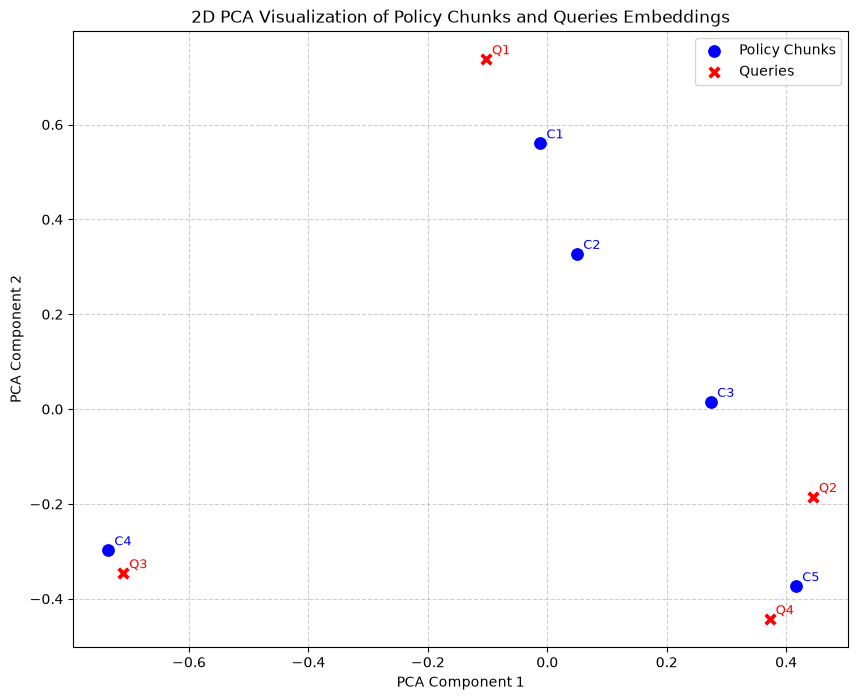

In [ ]:
# Combine all embeddings for visualization
all_embeddings = np.vstack((chunk_embeddings, query_embeddings))

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Separate back into chunk and query reduced embeddings
reduced_chunk_embeddings = reduced_embeddings[:len(chunks)]
reduced_query_embeddings = reduced_embeddings[len(chunks):]

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=reduced_chunk_embeddings[:, 0],
    y=reduced_chunk_embeddings[:, 1],
    label='Policy Chunks',
    color='blue',
    s=100, # size of points
    marker='o' # marker style
)
sns.scatterplot(
    x=reduced_query_embeddings[:, 0],
    y=reduced_query_embeddings[:, 1],
    label='Queries',
    color='red',
    s=100, # size of points
    marker='X' # marker style
)

# Annotate points (optional, for better understanding)
for i, chunk in enumerate(chunks):
    plt.text(reduced_chunk_embeddings[i, 0] + 0.01, reduced_chunk_embeddings[i, 1] + 0.01, f"C{i+1}", fontsize=9, color='blue')

for i, query in enumerate(queries):
    plt.text(reduced_query_embeddings[i, 0] + 0.01, reduced_query_embeddings[i, 1] + 0.01, f"Q{i+1}", fontsize=9, color='red')

plt.title('2D PCA Visualization of Policy Chunks and Queries Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Analysis: Why semantically similar texts appear closer together

The visualization clearly shows that semantically similar texts, such as a query about casual leaves and the policy chunk regarding casual leaves, are positioned closer to each other in the 2D space. This phenomenon is a fundamental property of good text embeddings, and it occurs for the following reasons:

1.  **Distributed Representation**: Embeddings are generated by neural networks that learn to represent words and sentences as dense vectors. This learning process is often trained on vast amounts of text data, where words and phrases that appear in similar contexts tend to have similar meanings.

2.  **Vector Space Semantics**: The embedding space is designed such that the geometric distance (e.g., Euclidean distance or cosine distance) between two vectors reflects the semantic similarity of the texts they represent. If two pieces of text have similar meanings, their corresponding vectors will be close together.

3.  **Dimensionality Reduction**: Techniques like PCA (Principal Component Analysis) or t-SNE reduce the high-dimensional embedding vectors to a lower-dimensional space (e.g., 2D for plotting) while trying to preserve the relative distances between points as much as possible. Therefore, if two vectors were close in the original high-dimensional space due to semantic similarity, they tend to remain close in the reduced 2D representation.

4.  **Contextual Meaning**: Modern embedding models (like Sentence-Transformers) are not just about individual words but capture the full contextual meaning of sentences. This allows them to understand paraphrases and conceptually similar ideas, even if the exact words differ.

In essence, the model has learned a mathematical representation where meaning is encoded by location in a multi-dimensional space, and distance in that space corresponds to semantic relatedness. This is why queries and chunks discussing the same topics (e.g., casual leaves, remote work, medical insurance) cluster together.